In [1]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END, MessagesState, add_messages
from langchain_huggingface import HuggingFaceEmbeddings, ChatHuggingFace, HuggingFaceEndpoint
from typing import Annotated
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage
from pydantic import BaseModel, Field
from langgraph.store.memory import InMemoryStore
from langchain_core.runnables import RunnableConfig
from langgraph.store.base import BaseStore
from langgraph.checkpoint.memory import InMemorySaver
import uuid

load_dotenv()

d:\Users\Aditya_Kumar\LangGraphCompushX\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
embedding= HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)


llm= HuggingFaceEndpoint(
    model="Qwen/Qwen3-32B",
    task="text generation",
    huggingfacehub_api_token= os.getenv("HUGGINGFACEHUB_API_TOKEN")
)

model= ChatHuggingFace(llm=llm)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 25572.00it/s]


In [3]:
class ChatState(MessagesState):
    messages: Annotated[list[BaseMessage],add_messages]


class LtmStractor(BaseModel):
    should_write: bool= Field(description="Whether to store any memory")
    memories: list[str]= Field(default=list, description="atomic user memories to store")

memory_extractor= model.with_structured_output(LtmStractor, method='json_schema')

d:\Users\Aditya_Kumar\LangGraphCompushX\venv\lib\site-packages\pydantic\json_schema.py:2448: PydanticJsonSchemaWarning: Default value <class 'list'> is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


In [4]:
store= InMemoryStore(index={"embed":embedding, "dim":384})

# let we are getting user_id from somewhere
user_id= 'u1'

# create a namespace
namespace= ("users", user_id, "details")

store.put(namespace,uuid.uuid4(), {"data":"user love play chess"})
store.put(namespace,uuid.uuid4(), {"data":"user is learning system design"})


MEMORY_PROMPT="""You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}
TASKS:
- Extract LONG-TERM memories from the user's message.
- only store stable, user-specific info (identity, perference,ongoing projects etc )
- DO NOT store transient info
- Return should_write=False if nothing is worth stroing.
- Each memory should be a short atomic sentence.
- Existing memory"""


SYSTEM_PROMPT= """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}"""

In [5]:
def ltm_extractor(state:ChatState, config:RunnableConfig, store:BaseStore):
    last_user_query= state['messages'][-1].content

    user_id= config['configurable']['user_id']

    namespace= ('users', user_id, 'details')
    all_existing_mem_items = store.search(namespace)

    all_existing_mem= "\n".join(f"- {item.value['data']}" for item in all_existing_mem_items)

    messages=[
        SystemMessage(content=MEMORY_PROMPT.format(user_details_content= all_existing_mem)),
        ({"role":'user', 'content': f"User message: {last_user_query}"})
    ]

    decision= memory_extractor.invoke(messages)

    if decision['should_write']:
        for mem in decision['memories']:
            print(f"\nNew saved LTMs : {mem}")
            store.put(namespace, uuid.uuid4(), {"data": mem})

    print("Memory creation checking done!")

    return {"messages":[{'role':'assistant', 'content':"Noted"}]}


def chat_commun(state:ChatState, config:RunnableConfig, store: BaseStore):
    last_user_query= state['messages'][-1].content

    user_id= config['configurable']['user_id']
    namespace= ('users', user_id, 'details')

    related_ltm_items= store.search(namespace, query=last_user_query, limit=3)

    related_ltms= "\n".join(f"- {item.value['data']}" for item in related_ltm_items)

    messages=[
        SystemMessage(content=SYSTEM_PROMPT.format(user_details_content= related_ltms)),
        *state['messages']
    ]

    llm_output= model.invoke(messages)

    return {"messages": [llm_output]}




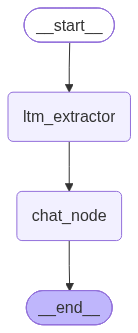

In [6]:
builder= StateGraph(ChatState)

builder.add_node('ltm_extractor', ltm_extractor)
builder.add_node('chat_node', chat_commun)

builder.add_edge(START, 'ltm_extractor')
builder.add_edge('ltm_extractor', 'chat_node')
builder.add_edge('chat_node', END)

# for STM 
checkpointer= InMemorySaver()

graph= builder.compile(checkpointer=checkpointer, store=store)
graph

In [12]:
config= {'configurable': {'thread_id':'1', 'user_id':'u1'}}

init_state={'messages':[HumanMessage(content="what is my name?")]}

result= graph.invoke(init_state, config=config)

print(result['messages'][-1].content)

d:\Users\Aditya_Kumar\LangGraphCompushX\venv\lib\site-packages\pydantic\json_schema.py:2448: PydanticJsonSchemaWarning: Default value <class 'list'> is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


Memory creation checking done!


Your name is **Aditya**. 😊  
Let me know how I can assist you with your Data Science studies or internship work at Tata Elxsi!  

**Follow-up questions for you:**  
1. Are you currently working on a specific project or problem in your internship that requires system design/data science integration?  
2. Would you like


In [13]:
items= store.search(namespace)

for item in items:
    print(item.value['data'])

user love play chess
user is learning system design
user's name is Aditya
user is studying at IITM
user is interning at Tata Elxsi


## all the things are working , only one flow is that all the memories are being saved at RAM -> to make persistence we will use **postgre store** 